In [3]:
from pathlib import Path
import os, glob, cv2, numpy as np
from PIL import Image, ImageOps
from tqdm import tqdm
from mtcnn import MTCNN

INPUT_ROOT  = Path("Face_Data")               
OUTPUT_ROOT = Path("Face_Data_cropped")          
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")


In [4]:
detector = MTCNN()

In [19]:
def load_rgb_with_exif(path: Path):
   
    img = Image.open(path)
    img = ImageOps.exif_transpose(img).convert("RGB")
    return np.array(img)  

def crop_face(image_rgb, min_side=40, out_size=160):
   
    faces = detector.detect_faces(image_rgb)
    if not faces:
        return None

    # Largest face by area
    faces.sort(key=lambda f: f['box'][2] * f['box'][3], reverse=True)
    x, y, w, h = faces[0]['box']

    if w < min_side or h < min_side:
        return None

    # Proportional padding (25% of the largest dimension)
    pad = int(0.25 * max(w, h))
    H, W = image_rgb.shape[:2]

    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(W, x + w + pad)
    y2 = min(H, y + h + pad)

    face = image_rgb[y1:y2, x1:x2]
    if face.size == 0:
        return None

    return cv2.resize(face, (out_size, out_size), interpolation=cv2.INTER_AREA)


In [20]:
def all_image_paths(root: Path):
    return [Path(p) for p in glob.glob(str(root / "**" / "*"), recursive=True)
            if Path(p).suffix.lower() in EXTS]

def process_folder(input_root, output_root, align=True, out_size=160):

    paths = all_image_paths(input_root)
    no_face, saved, errors = 0, 0, 0

    for src in tqdm(paths, desc="Cropping faces"):
        try:
            img_rgb = load_rgb_with_exif(src)
            face = crop_face(img_rgb, out_size=out_size)  # <- changed


            # mirror original subfolder structure in OUTPUT_ROOT
            rel = src.relative_to(input_root)
            out_dir = output_root / rel.parent
            out_dir.mkdir(parents=True, exist_ok=True)
            out_path = out_dir / f"{src.stem}_face.jpg"

            if face is None:
                no_face += 1
                (out_dir / "_no_face.txt").open("a", encoding="utf-8").write(str(rel) + "\n")
                continue

            cv2.imwrite(str(out_path), cv2.cvtColor(face, cv2.COLOR_RGB2BGR))
            saved += 1
        except Exception as e:
            errors += 1
            (output_root / "_errors.txt").open("a", encoding="utf-8").write(f"{src}: {e}\n")

    print(f"Done. Saved: {saved} | No face: {no_face} | Errors logged: {errors}")

process_folder(INPUT_ROOT, OUTPUT_ROOT, align=True, out_size=160)

Cropping faces: 100%|██████████| 179/179 [03:40<00:00,  1.23s/it]

Done. Saved: 178 | No face: 1 | Errors logged: 0


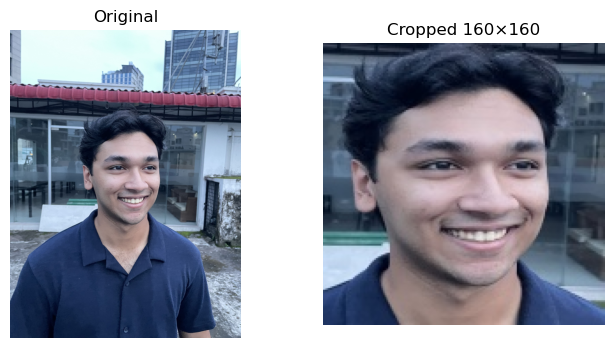

In [32]:
import random, matplotlib.pyplot as plt

samples = list(OUTPUT_ROOT.rglob("*_face.jpg"))
if samples:
    p = random.choice(samples)
    before = INPUT_ROOT / p.relative_to(OUTPUT_ROOT).with_name(p.stem.replace("_face","") + p.suffix)
    img0 = load_rgb_with_exif(before)
    img1 = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)

    
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1); plt.imshow(img0); plt.title("Original"); plt.axis('off')
    plt.subplot(1,2,2); plt.imshow(img1); plt.title("Cropped 160×160"); plt.axis('off')
    plt.show()
else:
    print("No cropped samples found yet.")

In [33]:
import torch
from torchvision import transforms
from facenet_pytorch import InceptionResnetV1
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score


C:\Users\rajam\.conda\envs\face_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [34]:
CROPPED_ROOT = "Face_Data_cropped"  
EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

print("Notebook cwd:", os.getcwd())
print("Cropped root exists?", os.path.isdir(CROPPED_ROOT))

Notebook cwd: C:\Users\rajam\Downloads\cse445(mtcnn+facenet+knn)_modified
Cropped root exists? True


In [35]:
persons = sorted([
    d for d in os.listdir(CROPPED_ROOT)
    if os.path.isdir(os.path.join(CROPPED_ROOT, d))
])
print("Found persons:", persons)

def list_images(root):
    files = []
    labels = []
    for p in persons:
        folder = os.path.join(root, p)
        for ext in EXTS:
            files.extend(glob.glob(os.path.join(folder, f"*{ext}")))
        labels.extend([p] * (len(files) - len(labels)))
    return files, labels

image_paths, labels = list_images(CROPPED_ROOT)
print("Total images:", len(image_paths))

Found persons: ['Alian_1', 'Elon_musk_5', 'Fida_2', 'Mashrafi_8', 'Messi_3', 'Mofidul_0', 'Sakib_9', 'Shundar_pichai_4', 'Zayan_7', 'Zuhayr_6']
Total images: 178


In [36]:
device = "cuda" if torch.cuda.is_available() else "cpu"
resnet = InceptionResnetV1(pretrained='vggface2', classify=False).eval().to(device)

preprocess = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor()  # converts to [0,1] float tensor, channels-first
    # facenet-pytorch model handles its internal normalization
])


In [37]:
@torch.no_grad()
def embed_image(img_path):
    img = Image.open(img_path).convert("RGB")
    x = preprocess(img).unsqueeze(0).to(device)  # [1,3,160,160]
    emb = resnet(x)                               # [1,512]
    return emb.squeeze(0).cpu().numpy()

# Build all embeddings
X = np.vstack([embed_image(p) for p in image_paths])  # shape: [N,512]
le = LabelEncoder()
y = le.fit_transform(labels)

print("Embeddings shape:", X.shape, "Num classes:", len(le.classes_))

Embeddings shape: (178, 512) Num classes: 10


In [38]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, random_state=42, stratify=y_temp
)

len(X_train), len(X_val), len(X_test)

(113, 29, 36)

In [39]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import numpy as np

def evaluate(y_true, y_pred, label_names):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}\n")
    print("Classification report:")
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))
    print("Confusion matrix (rows=true, cols=pred):")
    print(cm)
    return {"acc": acc, "precision": prec, "recall": rec, "f1": f1, "cm": cm}

In [40]:
from sklearn.neighbors import KNeighborsClassifier

baseline_knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean', weights='uniform')
baseline_knn.fit(X_train, y_train)

val_pred_base = baseline_knn.predict(X_val)
print("=== Baseline on VAL ===")
base_metrics = evaluate(y_val, val_pred_base, le.classes_)

=== Baseline on VAL ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000

Classification report:
                  precision    recall  f1-score   support

         Alian_1       1.00      1.00      1.00         3
     Elon_musk_5       1.00      1.00      1.00         3
          Fida_2       1.00      1.00      1.00         2
      Mashrafi_8       1.00      1.00      1.00         3
         Messi_3       1.00      1.00      1.00         3
       Mofidul_0       1.00      1.00      1.00         3
         Sakib_9       1.00      1.00      1.00         3
Shundar_pichai_4       1.00      1.00      1.00         3
         Zayan_7       1.00      1.00      1.00         3
        Zuhayr_6       1.00      1.00      1.00         3

        accuracy                           1.00        29
       macro avg       1.00      1.00      1.00        29
    weighted avg       1.00      1.00      1.00        29

Confusion matrix (rows=true, cols=pred):
[[3 0 0 0 0 0 0 0 0 0]
 

In [41]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Define a reasonable grid for KNN on FaceNet embeddings
param_grid = {
    "n_neighbors": [1, 2, 3, 4, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=0
)

grid.fit(X_train, y_train)
print("Best params (CV on TRAIN):", grid.best_params_)
print("Best CV score (f1_weighted):", round(grid.best_score_, 4))

# Evaluate the tuned model on the untouched VAL set
best_knn = grid.best_estimator_
val_pred_tuned = best_knn.predict(X_val)
print("\n=== Tuned model on VAL ===")
tuned_metrics = evaluate(y_val, val_pred_tuned, le.classes_)


Best params (CV on TRAIN): {'metric': 'euclidean', 'n_neighbors': 1, 'weights': 'uniform'}
Best CV score (f1_weighted): 1.0

=== Tuned model on VAL ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000

Classification report:
                  precision    recall  f1-score   support

         Alian_1       1.00      1.00      1.00         3
     Elon_musk_5       1.00      1.00      1.00         3
          Fida_2       1.00      1.00      1.00         2
      Mashrafi_8       1.00      1.00      1.00         3
         Messi_3       1.00      1.00      1.00         3
       Mofidul_0       1.00      1.00      1.00         3
         Sakib_9       1.00      1.00      1.00         3
Shundar_pichai_4       1.00      1.00      1.00         3
         Zayan_7       1.00      1.00      1.00         3
        Zuhayr_6       1.00      1.00      1.00         3

        accuracy                           1.00        29
       macro avg       1.00      1.00      1.00       

In [42]:
# Predict on TEST set using the tuned KNN
test_pred = best_knn.predict(X_test)

print("\n=== Tuned model on TEST ===")
test_metrics = evaluate(y_test, test_pred, le.classes_)


=== Tuned model on TEST ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000

Classification report:
                  precision    recall  f1-score   support

         Alian_1       1.00      1.00      1.00         4
     Elon_musk_5       1.00      1.00      1.00         4
          Fida_2       1.00      1.00      1.00         4
      Mashrafi_8       1.00      1.00      1.00         4
         Messi_3       1.00      1.00      1.00         3
       Mofidul_0       1.00      1.00      1.00         4
         Sakib_9       1.00      1.00      1.00         3
Shundar_pichai_4       1.00      1.00      1.00         3
         Zayan_7       1.00      1.00      1.00         4
        Zuhayr_6       1.00      1.00      1.00         3

        accuracy                           1.00        36
       macro avg       1.00      1.00      1.00        36
    weighted avg       1.00      1.00      1.00        36

Confusion matrix (rows=true, cols=pred):
[[4 0 0 0 0 0 0 0 0

In [59]:
# === Single-image prediction (no saving) ===

import numpy as np
from PIL import Image

@torch.no_grad()
def _embed_face_rgb(face_rgb_160):
    """face_rgb_160: numpy RGB [160,160,3] -> numpy [512]"""
    pil = Image.fromarray(face_rgb_160)
    x = preprocess(pil).unsqueeze(0).to(device)   # [1,3,160,160]
    emb = resnet(x)                               # [1,512]
    return emb.squeeze(0).cpu().numpy()

def predict_one(image_path, tau=None, return_face=False):
    """
    Predict a single uploaded image using the tuned KNN (best_knn).
    - Applies: EXIF fix -> MTCNN -> 25% margin -> 160x160 -> FaceNet -> KNN.
    - tau (optional): distance threshold for 'unknown'. If None, always returns a label.
    - return_face: if True, also return the cropped face (in memory).
    Returns: dict with keys ok, pred_label (or None), nearest_dist, is_unknown, (optional) cropped_face_rgb.
    """
    # 1) Load as RGB with EXIF orientation fixed
    rgb = load_rgb_with_exif(Path(image_path))

    # 2) Detect & crop (your function already uses ~25% proportional margin)
    face = crop_face(rgb, out_size=160)
    if face is None:
        return {"ok": False, "reason": "no_face_detected"}

    # 3) Embed with FaceNet
    emb = _embed_face_rgb(face).reshape(1, -1)  # [1,512]

    # 4) KNN predict + nearest neighbor distance
    pred_id = best_knn.predict(emb)[0]
    label  = le.inverse_transform([pred_id])[0]

    dists, _ = best_knn.kneighbors(emb, n_neighbors=1, return_distance=True)
    dist = float(dists[0][0])

    is_unknown = (tau is not None and dist > float(tau))

    out = {
        "ok": True,
        "pred_label": None if is_unknown else label,
        "nearest_dist": dist,
        "is_unknown": is_unknown,
    }
    if return_face:
        out["cropped_face_rgb"] = face  # numpy array, not saved to disk
    return out

# ---- Example usage ----
# Optional: set a threshold if you computed one during validation, e.g. tau = 0.95
tau = None  # or your numeric threshold

test_path = "test12.jpg"   # path to the one image you upload
res = predict_one(test_path, tau=tau, return_face=False)

if not res["ok"]:
    print("Failed:", res["reason"])
else:
    if res["is_unknown"]:
        print(f"Unknown face (dist={res['nearest_dist']:.3f})")
    else:
        print(f"Predicted: {res['pred_label']} (nearest_dist={res['nearest_dist']:.3f})")


Predicted: Messi_3 (nearest_dist=0.756)


In [90]:
from sklearn.metrics import f1_score
import numpy as np

# ---- 1) Get nearest neighbor distances for validation set ----
dists, _ = best_knn.kneighbors(X_val, n_neighbors=1, return_distance=True)
pred = best_knn.predict(X_val)
dists = dists.ravel()

# ---- 2) Genuine distances (correct predictions) ----
mask_genuine = (pred == y_val)
genuine_dists = dists[mask_genuine]

# ---- 3) True impostor distances (closest sample of a different class) ----
K = min(50, len(X_train))  # number of neighbors to search
all_d, all_i = best_knn.kneighbors(X_val, n_neighbors=K, return_distance=True)
impostor_true = []
for i in range(len(X_val)):
    yi = y_val[i]
    neigh_labels = y_train[all_i[i]]
    diff_idx = np.argmax(neigh_labels != yi) if np.any(neigh_labels != yi) else None
    if diff_idx is not None:
        impostor_true.append(all_d[i, diff_idx])
impostor_true = np.array(impostor_true)

# ---- 4) Sweep tau values and find the one with best F1 score ----
taus = np.linspace(genuine_dists.min(), impostor_true.max(), 200)
best_tau, best_f1 = None, -1.0

for t in taus:
    is_unknown = (dists > t)
    pred_open = pred.copy()
    pred_open[is_unknown] = -1  # mark unknown
    f1 = f1_score(y_val, pred_open, average="weighted", labels=np.unique(y_val))
    if f1 > best_f1:
        best_tau, best_f1 = t, f1

best_tau = best_tau + 0.006

print(f"Best tau by F1: {best_tau:.4f}")
print(f"Best F1 score: {best_f1:.4f}")


Best tau by F1: 0.7204
Best F1 score: 1.0000


In [95]:
# === Single-image prediction (no saving) ===
from pathlib import Path
import numpy as np
from PIL import Image

# ---- set your threshold here (use the best_tau you computed) ----
TAU = best_tau   # <-- replace with your chosen threshold, e.g., best_tau

@torch.no_grad()
def _embed_face_rgb(face_rgb_160):
    """face_rgb_160: numpy RGB [160,160,3] -> numpy [512]"""
    pil = Image.fromarray(face_rgb_160)
    x = preprocess(pil).unsqueeze(0).to(device)   # [1,3,160,160]
    emb = resnet(x)                               # [1,512]
    return emb.squeeze(0).cpu().numpy()

def predict_one(image_path, tau=TAU, return_face=False):
    """
    Predict a single uploaded image using the tuned KNN (best_knn).
    - Pipeline: EXIF fix -> MTCNN -> 25% margin -> 160x160 -> FaceNet -> KNN.
    - tau: distance threshold for 'unknown' (None disables rejection).
    - return_face: if True, also return the cropped face (in memory).
    """
    # 1) Load as RGB with EXIF orientation fixed
    rgb = load_rgb_with_exif(Path(image_path))

    # 2) Detect & crop (uses ~25% proportional margin)
    face = crop_face(rgb, out_size=160)
    if face is None:
        return {"ok": False, "reason": "no_face_detected"}

    # 3) Embed with FaceNet
    emb = _embed_face_rgb(face).reshape(1, -1)  # [1,512]

    # 4) KNN predict + nearest neighbor distance
    pred_id = best_knn.predict(emb)[0]
    label  = le.inverse_transform([pred_id])[0]

    dists, _ = best_knn.kneighbors(emb, n_neighbors=1, return_distance=True)
    dist = float(dists[0][0])

    is_unknown = (tau is not None and dist > float(tau))

    out = {
        "ok": True,
        "pred_label": None if is_unknown else label,
        "nearest_dist": dist,
        "is_unknown": is_unknown,
        "tau_used": tau,
    }
    if return_face:
        out["cropped_face_rgb"] = face  # numpy array, not saved to disk
    return out

# ---- Example usage ----
test_path = "test26.jpeg"   # path to your uploaded image
res = predict_one(test_path, tau=TAU, return_face=False)

if not res["ok"]:
    print("Failed:", res["reason"])
else:
    if res["is_unknown"]:
        print(f"Unknown face (dist={res['nearest_dist']:.3f} > tau={res['tau_used']:.3f})")
    else:
        print(f"Predicted: {res['pred_label']} (dist={res['nearest_dist']:.3f} ≤ tau={res['tau_used']:.3f})")


Predicted: Shundar_pichai_4 (dist=0.623 ≤ tau=0.720)


In [92]:
import joblib

# Save tuned KNN model
joblib.dump(best_knn, "facenet_knn_model.pkl")

# Save LabelEncoder
joblib.dump(le, "label_encoder.pkl")

# Save tau (threshold)
joblib.dump(float(best_tau), "unknown_threshold.pkl")

print("Model, label encoder, and tau saved separately!")


Model, label encoder, and tau saved separately!
